# ID6105 Assignment 03
**Madhav Pradeep (ME24B038)**

In [1]:
%matplotlib inline
import time
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 110

## Problem 1: Toeplitz matrix times a vector

`t` holds the 2n-1 values of the matrix, with `T[i, j] = t[(i - j) + (n - 1)]`.
A block of size m sitting at offset d (entries `t[i - j + d]`) is the slice
`t[d + n - m : d + n + m - 1]`.

In [2]:
def toeplitz_dense(t):
    n = (len(t) + 1) // 2
    idx = np.arange(n)[:, None] - np.arange(n)[None, :] + (n - 1)
    return t[idx]


def matvec_direct(t, x):
    return toeplitz_dense(t) @ x


def matvec_fast(t, x, cutoff=64):
    """y = T x using three half size products instead of four."""
    n = len(x)
    if n <= cutoff:
        return toeplitz_dense(t) @ x
    m = n // 2
    blk = lambda d: t[d + n - m: d + n + m - 1]     # Toeplitz block at offset d
    A, B, C = blk(0), blk(-m), blk(m)               # T = [[A, B], [C, A]]
    x1, x2 = x[:m], x[m:]
    P1 = matvec_fast(A, x1 + x2, cutoff)
    P2 = matvec_fast(B - A, x2, cutoff)
    P3 = matvec_fast(C - A, x1, cutoff)
    return np.concatenate([P1 + P2, P1 + P3])


rng = np.random.default_rng(38)
n = 256
t = rng.standard_normal(2 * n - 1)
x = rng.standard_normal(n)
print("max error against the direct product:",
      np.max(np.abs(matvec_fast(t, x) - matvec_direct(t, x))))

max error against the direct product: 2.042810365310288e-14


In [3]:
def op_counts(n, cutoff=64):
    """Exact number of multiplications and additions used by matvec_fast."""
    if n <= cutoff:
        return n * n, n * (n - 1)              # dense base case
    m = n // 2
    mul, add = op_counts(m, cutoff)
    return 3 * mul, 3 * add + 7 * m - 2        # x1+x2, B-A, C-A, P1+P2, P1+P3


print(f"{'n':>7} {'mults (fast)':>14} {'mults (direct)':>15} {'ratio':>8}")
ns = [2**k for k in range(7, 15)]
mults = []
for n in ns:
    mul, add = op_counts(n)
    mults.append(mul)
    print(f"{n:>7} {mul:>14,} {n*n:>15,} {n*n/mul:>8.1f}")
print(f"\nslope of the operation count: {np.polyfit(np.log(ns), np.log(mults), 1)[0]:.4f}"
      f"  (log2 3 = {math.log2(3):.4f})")

      n   mults (fast)  mults (direct)    ratio
    128         12,288          16,384      1.3
    256         36,864          65,536      1.8
    512        110,592         262,144      2.4
   1024        331,776       1,048,576      3.2
   2048        995,328       4,194,304      4.2
   4096      2,985,984      16,777,216      5.6
   8192      8,957,952      67,108,864      7.5
  16384     26,873,856     268,435,456     10.0

slope of the operation count: 1.5850  (log2 3 = 1.5850)


In [4]:
def timed(f, t, x, repeats=5):
    best = math.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(t, x)
        best = min(best, time.perf_counter() - t0)
    return best


sizes_fast = [2**k for k in range(9, 16)]      # 512 ... 32768
sizes_dir = [2**k for k in range(9, 13)]       # the dense matrix gets heavy after this
t_fast, t_dir = [], []
print(f"{'n':>6} {'fast (ms)':>10} {'direct (ms)':>12}")
for n in sizes_fast:
    t = rng.standard_normal(2 * n - 1)
    x = rng.standard_normal(n)
    tf = timed(matvec_fast, t, x)
    t_fast.append(tf)
    if n in sizes_dir:
        td = timed(matvec_direct, t, x)
        t_dir.append(td)
        print(f"{n:>6} {tf*1e3:>10.2f} {td*1e3:>12.2f}")
    else:
        print(f"{n:>6} {tf*1e3:>10.2f} {'-':>12}")

sf = np.polyfit(np.log(sizes_fast[-4:]), np.log(t_fast[-4:]), 1)[0]
sd = np.polyfit(np.log(sizes_dir[-3:]), np.log(t_dir[-3:]), 1)[0]
print(f"\nfitted slope  fast  : {sf:.3f}   (log2 3 = {math.log2(3):.3f})")
print(f"fitted slope  direct: {sd:.3f}   (expected 2)")

     n  fast (ms)  direct (ms)
   512       0.52         2.10
  1024       1.38         3.69


  2048       2.58        15.22


  4096       9.13        96.61
  8192      28.58            -


 16384      77.94            -


 32768     242.97            -

fitted slope  fast  : 1.565   (log2 3 = 1.585)
fitted slope  direct: 2.356   (expected 2)


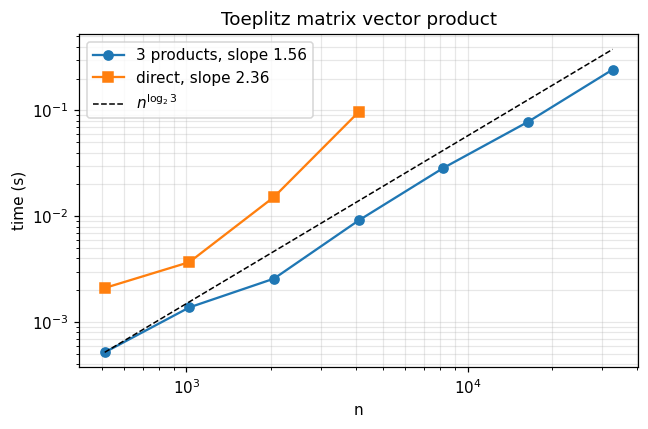

In [5]:
plt.loglog(sizes_fast, t_fast, "o-", label=f"3 products, slope {sf:.2f}")
plt.loglog(sizes_dir, t_dir, "s-", label=f"direct, slope {sd:.2f}")
ref = np.array(sizes_fast, float)
plt.loglog(ref, t_fast[0] * (ref / ref[0])**math.log2(3), "k--", lw=1, label=r"$n^{\log_2 3}$")
plt.xlabel("n"); plt.ylabel("time (s)"); plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.title("Toeplitz matrix vector product")
plt.tight_layout(); plt.savefig("fig1_toeplitz.png"); plt.show()

## Problem 2: Shortest path on a grid

In [6]:
def dp_table(cost):
    cost = np.asarray(cost, float)
    n, m = cost.shape
    dp = np.zeros_like(cost)
    dp[0, 0] = cost[0, 0]
    for j in range(1, m):
        dp[0, j] = dp[0, j - 1] + cost[0, j]
    for i in range(1, n):
        dp[i, 0] = dp[i - 1, 0] + cost[i, 0]
        for j in range(1, m):
            dp[i, j] = cost[i, j] + min(dp[i - 1, j], dp[i, j - 1])
    return dp


def best_path(cost, dp):
    i, j = len(dp) - 1, len(dp[0]) - 1
    path = [(i, j)]
    while (i, j) != (0, 0):
        if i == 0 or (j > 0 and dp[i][j - 1] <= dp[i - 1][j]):
            j -= 1
        else:
            i -= 1
        path.append((i, j))
    return path[::-1]


def brute_force(cost):
    """Try every path. Returns the best cost and the number of paths tried."""
    n, m = len(cost), len(cost[0])
    best, count = math.inf, 0
    for moves in set(itertools.permutations("D" * (n - 1) + "R" * (m - 1))):
        i = j = 0
        total = cost[0][0]
        for mv in moves:
            i, j = (i + 1, j) if mv == "D" else (i, j + 1)
            total += cost[i][j]
        best = min(best, total)
        count += 1
    return best, count


small = [[1, 3, 1],
         [1, 5, 1],
         [4, 2, 1]]
dp = dp_table(small)
print("DP table:\n", dp.astype(int))
print("optimal cost:", dp[-1, -1])
print("optimal path:", best_path(small, dp))
print("brute force: cost %d over %d paths" % brute_force(small))

DP table:
 [[1 4 5]
 [2 7 6]
 [6 8 7]]
optimal cost: 7.0
optimal path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]
brute force: cost 7 over 6 paths


In [7]:
big = [[1, 4, 8, 5, 7, 10, 3, 7],
       [8, 5, 4, 8, 8, 3, 6, 5],
       [2, 8, 6, 2, 5, 1, 10, 6],
       [9, 1, 10, 3, 7, 4, 9, 3],
       [5, 3, 7, 5, 9, 7, 2, 4],
       [9, 2, 10, 9, 10, 5, 2, 4],
       [7, 8, 3, 1, 4, 2, 8, 4],
       [2, 6, 6, 10, 4, 6, 2, 1]]
dpb = dp_table(big)
print("DP table:")
print(dpb.astype(int))
path = best_path(big, dpb)
print("\noptimal cost:", dpb[-1, -1])
print("optimal path:", path)
print("cells      :", [big[i][j] for i, j in path])

DP table:
[[ 1  5 13 18 25 35 38 45]
 [ 9 10 14 22 30 33 39 44]
 [11 18 20 22 27 28 38 44]
 [20 19 29 25 32 32 41 44]
 [25 22 29 30 39 39 41 45]
 [34 24 34 39 49 44 43 47]
 [41 32 35 36 40 42 50 51]
 [43 38 41 46 44 48 50 51]]

optimal cost: 51.0
optimal path: [(0, 0), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (7, 5), (7, 6), (7, 7)]
cells      : [1, 4, 5, 8, 1, 3, 2, 8, 3, 1, 4, 2, 6, 2, 1]


### (e) Bellman principle: every prefix of the optimal path is optimal

In [8]:
run = 0
print(f"{'cell':>8} {'cost along path':>16} {'DP value':>9}")
for i, j in path:
    run += big[i][j]
    print(f"{str((i, j)):>8} {run:>16} {dpb[i, j]:>9.0f}")
print("all prefixes optimal:", all(sum(big[a][b] for a, b in path[:k + 1]) == dpb[i, j]
                                  for k, (i, j) in enumerate(path)))

    cell  cost along path  DP value
  (0, 0)                1         1
  (0, 1)                5         5
  (1, 1)               10        10
  (2, 1)               18        18
  (3, 1)               19        19
  (4, 1)               22        22
  (5, 1)               24        24
  (6, 1)               32        32
  (6, 2)               35        35
  (6, 3)               36        36
  (6, 4)               40        40
  (6, 5)               42        42
  (7, 5)               48        48
  (7, 6)               50        50
  (7, 7)               51        51
all prefixes optimal: True


### (f) Random grids and complexity

In [9]:
rng2 = np.random.default_rng(38)
g = rng2.integers(1, 11, size=(5, 5))
print(g)
print("optimal cost:", dp_table(g)[-1, -1])

print(f"\n{'n':>6} {'time (ms)':>10}")
sizes, times = [100, 200, 400, 800, 1600], []
for n in sizes:
    grid = rng2.integers(1, 11, size=(n, n))
    t0 = time.perf_counter()
    dp_table(grid)
    times.append(time.perf_counter() - t0)
    print(f"{n:>6} {times[-1]*1e3:>10.1f}")
print(f"fitted slope: {np.polyfit(np.log(sizes), np.log(times), 1)[0]:.2f}  (expected 2)")

[[ 3  5  4  3  4]
 [ 8  5  7  2 10]
 [ 2  1  6  9  8]
 [ 5  9  5  8  5]
 [ 7  2  2  1  9]]
optimal cost: 37.0

     n  time (ms)
   100        5.2
   200       21.5
   400       78.3


   800      373.7


  1600     1249.1
fitted slope: 1.99  (expected 2)


## Problem 3: Coin change

In [10]:
def brute_force_coins(amount, coins):
    """Smallest number of coins, by searching over all multisets."""
    best = None
    maxima = [amount // c for c in coins]
    for counts in itertools.product(*[range(m + 1) for m in maxima]):
        if sum(c * k for c, k in zip(coins, counts)) == amount:
            if best is None or sum(counts) < sum(best):
                best = counts
    return best


def greedy(amount, coins):
    out = []
    for c in sorted(coins, reverse=True):
        while amount >= c:
            out.append(c)
            amount -= c
    return out if amount == 0 else None


COINS = [1, 2, 5, 10, 20]
b = brute_force_coins(38, COINS)
print("brute force 38:", [c for c, k in zip(COINS, b) for _ in range(k)], "->", sum(b), "coins")
print("greedy     38:", greedy(38, COINS), "->", len(greedy(38, COINS)), "coins")
for amount in [7, 38, 63, 99, 143]:
    g = greedy(amount, COINS)
    print(f"amount {amount:>4}: greedy {g} ({len(g)} coins)")

brute force 38: [1, 2, 5, 10, 20] -> 5 coins
greedy     38: [20, 10, 5, 2, 1] -> 5 coins
amount    7: greedy [5, 2] (2 coins)
amount   38: greedy [20, 10, 5, 2, 1] (5 coins)
amount   63: greedy [20, 20, 20, 2, 1] (5 coins)
amount   99: greedy [20, 20, 20, 20, 10, 5, 2, 2] (8 coins)
amount  143: greedy [20, 20, 20, 20, 20, 20, 20, 2, 1] (9 coins)


### (d), (e) Denominations [1, 3, 4]

In [11]:
def dp_coins(amount, coins):
    """min[a] = fewest coins for a, pick[a] = a coin used in an optimal solution."""
    INF = math.inf
    best = [0] + [INF] * amount
    pick = [None] * (amount + 1)
    for a in range(1, amount + 1):
        for c in coins:
            if c <= a and best[a - c] + 1 < best[a]:
                best[a], pick[a] = best[a - c] + 1, c
    coinset, a = [], amount
    while a > 0:
        coinset.append(pick[a])
        a -= pick[a]
    return best, coinset


ODD = [1, 3, 4]
best, _ = dp_coins(12, ODD)
print(f"{'amount':>7} {'greedy':>22} {'n':>3} {'DP':>14} {'n':>3}")
for a in range(1, 13):
    g = greedy(a, ODD)
    d = dp_coins(a, ODD)[1]
    flag = "   <-- greedy not optimal" if len(g) > len(d) else ""
    print(f"{a:>7} {str(g):>22} {len(g):>3} {str(d):>14} {len(d):>3}{flag}")
print("\nDP table min[0..12]:", [int(v) for v in best])

 amount                 greedy   n             DP   n
      1                    [1]   1            [1]   1
      2                 [1, 1]   2         [1, 1]   2
      3                    [3]   1            [3]   1
      4                    [4]   1            [4]   1
      5                 [4, 1]   2         [1, 4]   2
      6              [4, 1, 1]   3         [3, 3]   2   <-- greedy not optimal
      7                 [4, 3]   2         [3, 4]   2
      8                 [4, 4]   2         [4, 4]   2
      9              [4, 4, 1]   3      [1, 4, 4]   3
     10           [4, 4, 1, 1]   4      [3, 3, 4]   3   <-- greedy not optimal
     11              [4, 4, 3]   3      [3, 4, 4]   3
     12              [4, 4, 4]   3      [4, 4, 4]   3

DP table min[0..12]: [0, 1, 2, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3]


## Problem 4: Area by random sampling

In [12]:
def shoelace(poly):
    p = np.asarray(poly, float)
    x, y = p[:, 0], p[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def inside(poly, pts):
    """Ray crossing test, vectorised over the sample points."""
    p = np.asarray(poly, float)
    x, y = pts[:, 0], pts[:, 1]
    res = np.zeros(len(pts), bool)
    for k in range(len(p)):
        x1, y1 = p[k]
        x2, y2 = p[(k + 1) % len(p)]
        crosses = (y1 > y) != (y2 > y)
        with np.errstate(divide="ignore", invalid="ignore"):
            xcut = x1 + (y - y1) * (x2 - x1) / (y2 - y1)
        res ^= crosses & (x < xcut)
    return res


def mc_area(poly, N, rng):
    p = np.asarray(poly, float)
    lo, hi = p.min(0), p.max(0)
    box = np.prod(hi - lo)
    pts = rng.uniform(lo, hi, size=(N, 2))
    return box * inside(poly, pts).mean()


POLY = [(0, 0), (8, 0), (8, 3), (5, 3), (5, 6), (2, 6), (0, 4)]
exact = shoelace(POLY)
rng = np.random.default_rng(38)
print("exact area (shoelace):", exact)
print("bounding rectangle   :", 8 * 6)
for N in [100, 1000, 10000, 100000]:
    print(f"N = {N:>7}: estimate {mc_area(POLY, N, rng):.4f}")

exact area (shoelace): 37.0
bounding rectangle   : 48
N =     100: estimate 36.0000
N =    1000: estimate 36.7200
N =   10000: estimate 36.7440
N =  100000: estimate 36.9931


       N  mean relative error
     100              0.04854
    1000              0.01360
   10000              0.00421
  100000              0.00132
 1000000              0.00046
fitted slope: -0.506  (expected -0.5)


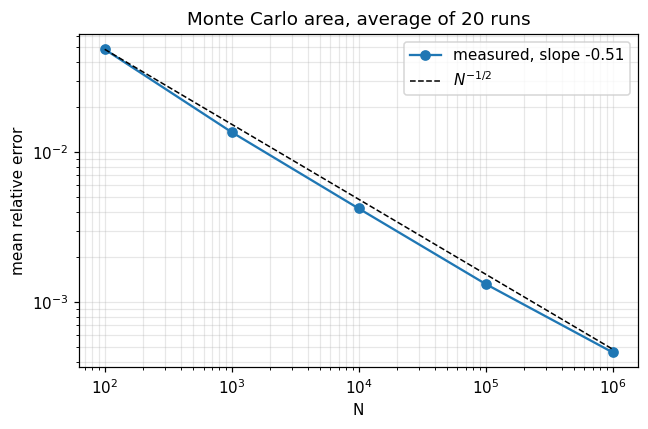

In [13]:
Ns = [10**k for k in range(2, 7)]
runs = 20
err = [np.mean([abs(mc_area(POLY, N, rng) - exact) / exact for _ in range(runs)]) for N in Ns]
slope = np.polyfit(np.log(Ns), np.log(err), 1)[0]
print(f"{'N':>8} {'mean relative error':>20}")
for N, e in zip(Ns, err):
    print(f"{N:>8} {e:>20.5f}")
print(f"fitted slope: {slope:.3f}  (expected -0.5)")

plt.loglog(Ns, err, "o-", label=f"measured, slope {slope:.2f}")
plt.loglog(Ns, err[0] * (np.array(Ns) / Ns[0])**-0.5, "k--", lw=1, label="$N^{-1/2}$")
plt.xlabel("N"); plt.ylabel("mean relative error"); plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.title("Monte Carlo area, average of 20 runs")
plt.tight_layout(); plt.savefig("fig2_mc_error.png"); plt.show()

### (c) The irregular shape, digitised from the figure (24 points, box 10 m by 12 m)

area of the digitised boundary: 64.848 m^2

       N  mean estimate   std dev  rel. spread
    1000         65.082     1.096       0.0168
   10000         64.890     0.350       0.0054


  100000         64.860     0.124       0.0019


 1000000         64.842     0.039       0.0006


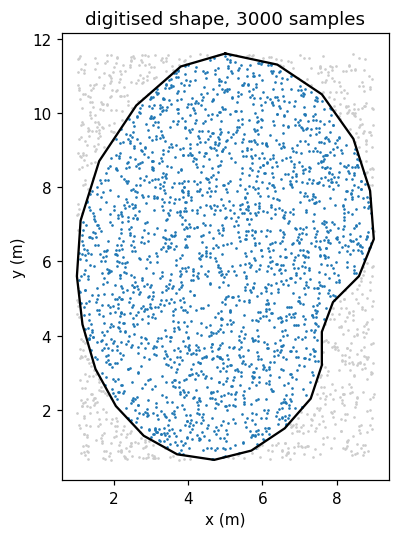

In [14]:
SHAPE = [(5.00, 11.60), (6.40, 11.30), (7.60, 10.50), (8.45, 9.30), (8.90, 7.90),
         (9.00, 6.60), (8.60, 5.60), (7.90, 4.90), (7.60, 4.10), (7.60, 3.20),
         (7.30, 2.30), (6.60, 1.50), (5.70, 0.90), (4.70, 0.65), (3.70, 0.80),
         (2.80, 1.30), (2.05, 2.10), (1.50, 3.10), (1.15, 4.30), (1.00, 5.60),
         (1.10, 7.10), (1.60, 8.70), (2.60, 10.20), (3.80, 11.25)]
area_poly = shoelace(SHAPE)
print(f"area of the digitised boundary: {area_poly:.3f} m^2")

print(f"\n{'N':>8} {'mean estimate':>14} {'std dev':>9} {'rel. spread':>12}")
for N in [10**k for k in range(3, 7)]:
    est = np.array([mc_area(SHAPE, N, rng) for _ in range(20)])
    print(f"{N:>8} {est.mean():>14.3f} {est.std():>9.3f} {est.std()/est.mean():>12.4f}")

pts = rng.uniform([min(p[0] for p in SHAPE), min(p[1] for p in SHAPE)],
                  [max(p[0] for p in SHAPE), max(p[1] for p in SHAPE)], size=(3000, 2))
ins = inside(SHAPE, pts)
sx = [p[0] for p in SHAPE] + [SHAPE[0][0]]
sy = [p[1] for p in SHAPE] + [SHAPE[0][1]]
plt.figure(figsize=(4.2, 5))
plt.plot(pts[ins, 0], pts[ins, 1], ".", ms=1.5, color="tab:blue")
plt.plot(pts[~ins, 0], pts[~ins, 1], ".", ms=1.5, color="0.8")
plt.plot(sx, sy, "k-", lw=1.5)
plt.gca().set_aspect("equal"); plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.title("digitised shape, 3000 samples")
plt.tight_layout(); plt.savefig("fig3_shape.png"); plt.show()

## Problem 5: Trajectory optimisation

With $u_0 = 0$ and $a$ the control, $u_k = dt\sum_{j<k} a_j$ and
$x_k = dt^2 \sum_j \max(0, k-1-j)\, a_j$, so both end states are linear in $a$
and the unconstrained problem is a least squares problem.

In [15]:
N, T = 100, 1.0
dt = T / N
j = np.arange(N)

# x_k and u_k as linear maps of the control vector a
Xmat = dt**2 * np.maximum(0, np.arange(N + 1)[:, None] - 1 - j[None, :])
Umat = dt * (np.arange(N + 1)[:, None] > j[None, :])
xN_row, uN_row = Xmat[N], Umat[N]


def single_integrator():
    u = np.full(N, 1.0 / T)                      # constant control
    return u, dt * np.sum(u**2)


u_opt, J1 = single_integrator()
print(f"(a) constant u = {u_opt[0]:.3f}, J = {J1:.4f}, analytic 1/T = {1/T:.4f}")
rng3 = np.random.default_rng(38)
worse = []
for _ in range(5):                               # feasible perturbations cost more
    d = rng3.standard_normal(N)
    d -= d.mean()                                # keeps sum u fixed, so x_N = 1 still
    worse.append(dt * np.sum((u_opt + 0.3 * d)**2))
print("    perturbed feasible controls:", [f"{w:.4f}" for w in worse])

(a) constant u = 1.000, J = 1.0000, analytic 1/T = 1.0000
    perturbed feasible controls: ['1.0992', '1.0727', '1.0832', '1.0818', '1.0896']


In [16]:
def solve_lsq(w):
    """Unconstrained minimiser of w[(x_N-1)^2 + u_N^2] + dt sum a_k^2."""
    M = np.vstack([np.sqrt(w) * xN_row, np.sqrt(w) * uN_row, np.sqrt(dt) * np.eye(N)])
    rhs = np.concatenate([[np.sqrt(w)], [0.0], np.zeros(N)])
    return np.linalg.lstsq(M, rhs, rcond=None)[0]


def report(a, tag):
    xN, uN = xN_row @ a, uN_row @ a
    effort = dt * np.sum(a**2)
    J = 1e4 * ((xN - 1)**2 + uN**2) + effort
    print(f"{tag:<16} x_N = {xN:8.5f}  u_N = {uN:9.5f}  effort = {effort:8.4f}  J(w=1e4) = {J:8.4f}")
    return xN, uN, effort


a_hi = solve_lsq(1e4)
a_lo = solve_lsq(1.0)
report(a_hi, "w = 1e4")
report(a_lo, "w = 1")
t_grid = dt * np.arange(N)
print("analytic (w -> inf): a(t) = 6 - 12t, effort = 12")
print("numerical a_0, a_N-1:", f"{a_hi[0]:.3f}", f"{a_hi[-1]:.3f}",
      "| max |a - (6-12t)| =", f"{np.max(np.abs(a_hi - (6 - 12 * t_grid))):.4f}")

w = 1e4          x_N =  0.99880  u_N =   0.00059  effort =  11.9654  J(w=1e4) =  11.9833
w = 1            x_N =  0.17070  u_N =   0.20525  effort =   0.0994  J(w=1e4) = 7298.7520
analytic (w -> inf): a(t) = 6 - 12t, effort = 12
numerical a_0, a_N-1: 5.932 -5.931 | max |a - (6-12t)| = 0.0677


### (c) Bounded control $|a_k| \le a_{max}$

In [17]:
W = 1e4
BANDS = [(0.4, 0.35, 0.50), (0.6, 0.50, 0.65)]      # (position, t start, t end)
tt = dt * np.arange(N + 1)
masks = [(tt >= t0) & (tt <= t1) for _, t0, t1 in BANDS]
MARGIN = 0.05                                        # clearance we ask for


def cost_and_grad(a, pen=0.0):
    xN, uN = xN_row @ a, uN_row @ a
    J = W * ((xN - 1)**2 + uN**2) + dt * np.sum(a**2)
    g = 2 * W * (xN - 1) * xN_row + 2 * W * uN * uN_row + 2 * dt * a
    if pen:                                          # debris penalty, part (d)
        x = Xmat @ a
        for (c, _, _), m in zip(BANDS, masks):
            d = x - c
            act = m & (MARGIN - np.abs(d) > 0)
            r = MARGIN - np.abs(d[act])
            J += pen * np.sum(r**2)
            g += -2 * pen * (Xmat[act].T @ (r * np.sign(d[act])))
    return J, g


def solve_bounded(amax, pen=0.0, a0=None):
    a0 = np.zeros(N) if a0 is None else a0
    res = minimize(cost_and_grad, a0, args=(pen,), jac=True, method="L-BFGS-B",
                   bounds=[(-amax, amax)] * N, options={"maxiter": 5000, "maxfun": 200000})
    return res.x


print(f"{'a_max':>6} {'x_N':>9} {'u_N':>9} {'effort':>9} {'J':>10}")
for amax in [2, 3, 3.5, 3.9, 4.0, 4.5, 6, 10]:
    a = solve_bounded(amax)
    print(f"{amax:>6} {xN_row @ a:>9.4f} {uN_row @ a:>9.4f} {dt*np.sum(a**2):>9.4f}"
          f" {cost_and_grad(a)[0]:>10.2f}")
print("\nbang bang limit: x_max = a_max T^2 / 4, so a_max >= 4 / T^2 =", 4 / T**2)

 a_max       x_N       u_N    effort          J
     2    0.5875    0.1856    3.9631    2049.83
     3    0.7973    0.0972    8.9152     514.44
   3.5    0.8991    0.0493   12.1479     138.15
   3.9    0.9795    0.0101   14.8147      20.05
   4.0    0.9944    0.0028   14.4655      14.85
   4.5    0.9985    0.0008   12.3971      12.43
     6    0.9988    0.0006   11.9654      11.98
    10    0.9988    0.0006   11.9654      11.98

bang bang limit: x_max = a_max T^2 / 4, so a_max >= 4 / T^2 = 4.0


### (d) Avoiding the debris

The penalty is non convex (the trajectory can go past the debris early or late), so the
optimisation is started from three different guesses and the cheapest result is kept.
The penalty weight is raised in stages so that the solver is not thrown off at the start.

In [18]:
def lsq_waypoints(way, w=1e4):
    """Least squares control that also passes close to the given (index, x) waypoints."""
    rows, rhs = [np.sqrt(w) * xN_row, np.sqrt(w) * uN_row], [np.sqrt(w), 0.0]
    for k, val in way:
        rows.append(np.sqrt(w) * Xmat[k])
        rhs.append(np.sqrt(w) * val)
    M = np.vstack(rows + [np.sqrt(dt) * np.eye(N)])
    return np.linalg.lstsq(M, np.concatenate([rhs, np.zeros(N)]), rcond=None)[0]


def clearances(x):
    return [np.min(np.abs(x[m] - c)) for (c, _, _), m in zip(BANDS, masks)]


a_free = solve_bounded(10.0)
starts = {"straight through": a_free,
          "pass late": lsq_waypoints([(50, 0.30), (65, 0.52)]),
          "pass early": lsq_waypoints([(35, 0.47), (50, 0.67)])}

results = {}
print(f"{'start':>17} {'x_N':>8} {'effort':>8} {'clearances':>18} {'J':>12}")
for name, a0 in starts.items():
    a = a0
    for pen in [1e3, 1e4, 1e5, 1e6]:                 # raise the penalty in stages
        a = solve_bounded(10.0, pen, a)
    x = Xmat @ a
    results[name] = (cost_and_grad(a, 1e6)[0], a)
    cl = clearances(x)
    print(f"{name:>17} {x[-1]:>8.4f} {dt*np.sum(a**2):>8.3f}"
          f" {cl[0]:>8.3f} {cl[1]:>8.3f} {results[name][0]:>12.2f}")

best = min(results, key=lambda k: results[k][0])
a_avoid = results[best][1]
x_avoid, x_free = Xmat @ a_avoid, Xmat @ a_free
print(f"\nbest start: {best}, max |a| = {np.max(np.abs(a_avoid)):.2f}")
print("free solution clearances:", [f"{c:.3f}" for c in clearances(x_free)])

            start      x_N   effort         clearances            J
 straight through   1.0006   34.302    0.007    0.007      9088.88


        pass late   0.9958   18.212    0.074    0.050        18.41
       pass early   1.0001   20.236    0.050    0.080        20.24

best start: pass late, max |a| = 10.00
free solution clearances: ['0.002', '0.004']


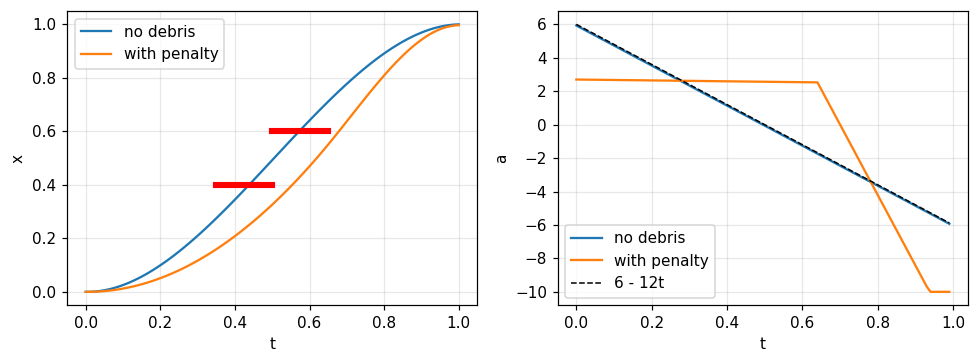

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(tt, x_free, label="no debris")
ax[0].plot(tt, x_avoid, label="with penalty")
ax[0].plot([0.35, 0.50], [0.4, 0.4], "r", lw=4)
ax[0].plot([0.50, 0.65], [0.6, 0.6], "r", lw=4)
ax[0].set_xlabel("t"); ax[0].set_ylabel("x"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(t_grid, a_free, label="no debris")
ax[1].plot(t_grid, a_avoid, label="with penalty")
ax[1].plot(t_grid, 6 - 12 * t_grid, "k--", lw=1, label="6 - 12t")
ax[1].set_xlabel("t"); ax[1].set_ylabel("a"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig4_trajectory.png"); plt.show()

## Problem 6: Recurrences

Nothing to run here, the working is in the report. The recursion tree for (d) is checked below.

In [20]:
def T_d(n):
    # T(n) = 2 T(n/2) + n log2(n)^2, T(1) = 1
    return 1.0 if n <= 1 else 2 * T_d(n // 2) + n * math.log2(n)**2


print(f"{'n':>7} {'T(n)':>12} {'T(n)/(n log^3 n)':>18}")
for k in range(4, 17):
    n = 2**k
    print(f"{n:>7} {T_d(n):>12.1f} {T_d(n)/(n*math.log2(n)**3):>18.4f}")

      n         T(n)   T(n)/(n log^3 n)
     16        496.0             0.4844
     32       1792.0             0.4480
     64       5888.0             0.4259
    128      18048.0             0.4111
    256      52480.0             0.4004
    512     146432.0             0.3923
   1024     395264.0             0.3860
   2048    1038336.0             0.3809
   4096    2666496.0             0.3767
   8192    6717440.0             0.3732
  16384   16646144.0             0.3703
  32768   40665088.0             0.3677
  65536   98107392.0             0.3655


## Problem 7: Order of multiplication of Jacobians

In [21]:
dims = [1, 200, 5000, 5000, 1000]        # J4 J3 J2 J1

right_to_left = 5000*5000*1000 + 200*5000*1000 + 1*200*1000
left_to_right = 1*200*5000 + 1*5000*5000 + 1*5000*1000
print(f"right to left  J4(J3(J2 J1)) : {right_to_left:,}")
print(f"left to right ((J4 J3)J2)J1  : {left_to_right:,}")
print(f"ratio                        : {right_to_left/left_to_right:.0f}")

right to left  J4(J3(J2 J1)) : 26,000,200,000
left to right ((J4 J3)J2)J1  : 31,000,000
ratio                        : 839


In [22]:
def matrix_chain(p):
    m = len(p) - 1
    M = [[0] * m for _ in range(m)]
    S = [[0] * m for _ in range(m)]
    for length in range(2, m + 1):
        for i in range(m - length + 1):
            j = i + length - 1
            M[i][j] = math.inf
            for k in range(i, j):
                c = M[i][k] + M[k + 1][j] + p[i] * p[k + 1] * p[j + 1]
                if c < M[i][j]:
                    M[i][j], S[i][j] = c, k
    return M, S


def bracket(S, names, i, j):
    if i == j:
        return names[i]
    k = S[i][j]
    return f"({bracket(S, names, i, k)}{bracket(S, names, k + 1, j)})"


M, S = matrix_chain(dims)
print("DP cost table M[i][j]:")
for row in M:
    print("  ", [f"{int(v):,}" if v else "0" for v in row])
print("\nminimum cost:", f"{int(M[0][3]):,}")
print("bracketing  :", bracket(S, ["J4", "J3", "J2", "J1"], 0, 3))
print("number of orders for m matrices (Catalan):",
      [math.comb(2 * (m - 1), m - 1) // m for m in range(2, 9)])

DP cost table M[i][j]:
   ['0', '1,000,000', '26,000,000', '31,000,000']
   ['0', '0', '5,000,000,000', '6,000,000,000']
   ['0', '0', '0', '25,000,000,000']
   ['0', '0', '0', '0']

minimum cost: 31,000,000
bracketing  : (((J4J3)J2)J1)
number of orders for m matrices (Catalan): [1, 2, 5, 14, 42, 132, 429]


## Problem 8: Relays along a pipeline

In [23]:
POS = [0, 7, 15, 19, 31, 38, 44, 52, 60, 63, 75, 82, 90]
COST = [4, 9, 3, 8, 6, 5, 7, 2, 9, 3, 8, 6, 4]
R = 20


def greedy_relays(pos, R):
    relays, i, n = [], 0, len(pos)
    while i < n:
        j = i
        while j + 1 < n and pos[j + 1] - pos[i] <= R:   # furthest site still covering pos[i]
            j += 1
        relays.append(pos[j])
        while i < n and pos[i] <= pos[j] + R:
            i += 1
    return relays


def min_cost_relays(pos, cost, R):
    """f[i] = cheapest way to cover sensors i..n-1."""
    n = len(pos)
    f = [math.inf] * n + [0.0]
    choice = [None] * n
    for i in range(n - 1, -1, -1):
        for j in range(n):
            if abs(pos[j] - pos[i]) <= R:               # a relay at site j covers sensor i
                nxt = i
                while nxt < n and pos[nxt] <= pos[j] + R:
                    nxt += 1
                if cost[j] + f[nxt] < f[i]:
                    f[i], choice[i] = cost[j] + f[nxt], (j, nxt)
    sites, i = [], 0
    while i < n:
        j, nxt = choice[i]
        sites.append(pos[j])
        i = nxt
    return f[0], sites


g = greedy_relays(POS, R)
print("greedy relays      :", g, "->", len(g), "relays, cost",
      sum(COST[POS.index(p)] for p in g))
best, sites = min_cost_relays(POS, COST, R)
print("cheapest cover (DP):", sites, "-> cost", int(best))
print("every sensor covered:", all(any(abs(p - s) <= R for s in sites) for p in POS))

greedy relays      : [19, 63, 90] -> 3 relays, cost 15
cheapest cover (DP): [15, 52, 90] -> cost 9
every sensor covered: True


## Problem 9: Choosing instruments (0/1 knapsack)

In [24]:
mass = [12, 7, 11, 8, 9, 6]
value = [24, 13, 23, 15, 16, 11]
BUDGET = 26


def greedy_knapsack(mass, value, W):
    order = sorted(range(len(mass)), key=lambda i: value[i] / mass[i], reverse=True)
    chosen, used = [], 0
    for i in order:
        if used + mass[i] <= W:
            chosen.append(i)
            used += mass[i]
    return chosen, used, sum(value[i] for i in chosen)


def knapsack(mass, value, W):
    n = len(mass)
    K = [[0] * (W + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(W + 1):
            K[i][w] = K[i - 1][w]
            if mass[i - 1] <= w:
                K[i][w] = max(K[i][w], K[i - 1][w - mass[i - 1]] + value[i - 1])
    chosen, w = [], W
    for i in range(n, 0, -1):
        if K[i][w] != K[i - 1][w]:
            chosen.append(i - 1)
            w -= mass[i - 1]
    return K, sorted(chosen)


print("value per kg:", [f"{v/m:.3f}" for m, v in zip(mass, value)])
ch, used, val = greedy_knapsack(mass, value, BUDGET)
print(f"greedy picks instruments {[i+1 for i in sorted(ch)]}, mass {used}, value {val}")

K, chosen = knapsack(mass, value, BUDGET)
print(f"DP optimum: instruments {[i+1 for i in chosen]}, mass {sum(mass[i] for i in chosen)}, value {K[-1][-1]}")
print("\nDP table K[i][W] (rows = first i instruments, columns W = 0..26):")
for i, row in enumerate(K):
    print(f"i={i}", " ".join(f"{v:>3}" for v in row))

value per kg: ['2.000', '1.857', '2.091', '1.875', '1.778', '1.833']
greedy picks instruments [1, 3], mass 23, value 47
DP optimum: instruments [2, 3, 4], mass 26, value 51

DP table K[i][W] (rows = first i instruments, columns W = 0..26):
i=0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
i=1   0   0   0   0   0   0   0   0   0   0   0   0  24  24  24  24  24  24  24  24  24  24  24  24  24  24  24
i=2   0   0   0   0   0   0   0  13  13  13  13  13  24  24  24  24  24  24  24  37  37  37  37  37  37  37  37
i=3   0   0   0   0   0   0   0  13  13  13  13  23  24  24  24  24  24  24  36  37  37  37  37  47  47  47  47
i=4   0   0   0   0   0   0   0  13  15  15  15  23  24  24  24  28  28  28  36  38  39  39  39  47  47  47  51
i=5   0   0   0   0   0   0   0  13  15  16  16  23  24  24  24  28  29  31  36  38  39  40  40  47  47  47  51
i=6   0   0   0   0   0   0  11  13  15  16  16  23  24  24  26  28  29  34  36  38  39 

In [25]:
# same problem in grams
mass_g = [m * 1000 for m in mass]
for W, ms in [(26, mass), (26_000, mass_g)]:
    t0 = time.perf_counter()
    K2, _ = knapsack(ms, value, W)
    print(f"budget {W:>7}: optimum {K2[-1][-1]}, time {(time.perf_counter()-t0)*1e3:8.2f} ms")

budget      26: optimum 51, time     0.03 ms
budget   26000: optimum 51, time    17.90 ms


## Problem 10: Verifying a matrix product (Freivalds)

In [26]:
def freivalds(A, B, C, trials, rng):
    n = len(A)
    for _ in range(trials):
        r = rng.integers(0, 2, size=n).astype(float)
        if np.any(np.abs(A @ (B @ r) - C @ r) > 1e-8):
            return False                 # certainly wrong
    return True                          # probably right


rng4 = np.random.default_rng(38)
n = 300
A = rng4.integers(0, 10, (n, n)).astype(float)
B = rng4.integers(0, 10, (n, n)).astype(float)
C = A @ B
print("correct product, 30 checks ->", freivalds(A, B, C, 30, rng4))

Cbad = C.copy()
Cbad[17, 42] += 1                        # one wrong entry
detected = sum(not freivalds(A, B, Cbad, 1, rng4) for _ in range(2000))
print(f"single check on a wrong product: detected {detected}/2000 = {detected/2000:.3f}")
print("30 checks on the wrong product ->", freivalds(A, B, Cbad, 30, rng4))

print()
for n2 in [300, 1500, 3000]:                 # the saving shows up as n grows
    A2 = rng4.integers(0, 10, (n2, n2)).astype(float)
    B2 = rng4.integers(0, 10, (n2, n2)).astype(float)
    t0 = time.perf_counter(); C2 = A2 @ B2; t_mul = time.perf_counter() - t0
    t0 = time.perf_counter(); freivalds(A2, B2, C2, 30, rng4); t_chk = time.perf_counter() - t0
    print(f"n = {n2:>4}: one product {t_mul*1e3:>8.1f} ms, 30 checks {t_chk*1e3:>7.1f} ms,"
          f" ratio {t_mul/t_chk:>5.2f}")
print("checks needed for failure probability below 1e-9:", math.ceil(9 / math.log10(2)))

correct product, 30 checks -> True


single check on a wrong product: detected 1020/2000 = 0.510
30 checks on the wrong product -> False



n =  300: one product      1.2 ms, 30 checks     4.8 ms, ratio  0.26


n = 1500: one product    114.0 ms, 30 checks    68.9 ms, ratio  1.66


n = 3000: one product    785.3 ms, 30 checks   332.1 ms, ratio  2.36
checks needed for failure probability below 1e-9: 30
